# Projekt końcowy — analiza danych i predykcja cen domów

Celem projektu jest analiza danych dotyczących sprzedaży domów oraz zbudowanie modelu predykcyjnego przewidującego `SalePrice`.

Notebook zawiera:
- wczytanie danych treningowych i testowych,
- eksploracyjną analizę danych,
- analizę braków danych,
- wizualizacje zależności między cechami a ceną,
- kodowanie zmiennych kategorycznych,
- uzupełnianie braków danych,
- podstawowe metody statystyczne,
- modele regresyjne i wygenerowanie pliku `submission.csv`.

## 1. Import bibliotek

W tej części importujemy biblioteki potrzebne do analizy danych, wizualizacji oraz modelowania regresyjnego.

In [1]:
# Podstawowe biblioteki do pracy z danymi
import pandas as pd
import numpy as np
import math

# Wizualizacja danych
import seaborn as sns
import matplotlib.pyplot as plt

# Metody statystyczne
from scipy.stats import pearsonr, spearmanr, f_oneway

# Modele i narzędzia machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ustawienia wykresów
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Wczytanie danych

W projekcie wykorzystuję pliki:
- `train.csv` — dane treningowe z kolumną docelową `SalePrice`,
- `test.csv` — dane testowe bez ceny, dla których na końcu generowana jest predykcja.

In [2]:
# Wczytanie danych z plików CSV znajdujących się w tym samym folderze co notebook
df = pd.read_csv("train.csv")
testowe = pd.read_csv("test.csv")

# Podgląd pierwszych wierszy danych treningowych
display(df.head())

print("Rozmiar danych treningowych:", df.shape)
print("Rozmiar danych testowych:", testowe.shape)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Rozmiar danych treningowych: (1460, 81)
Rozmiar danych testowych: (1459, 80)


## 3. Pytania badawcze

W analizie odpowiadam na następujące pytania:

1. Jak wygląda rozkład cen domów (`SalePrice`)?
2. Które zmienne numeryczne są najmocniej skorelowane z ceną domu?
3. Czy większa powierzchnia mieszkalna (`GrLivArea`) wiąże się z wyższą ceną?
4. Czy wyższa jakość domu i jego elementów, np. `ExterQual`, `KitchenQual`, `BsmtQual`, wpływa na cenę?
5. Które dzielnice (`Neighborhood`) mają najwyższe średnie ceny domów?
6. Jak dobrze modele regresyjne przewidują cenę sprzedaży domu?

## 4. Podstawowa eksploracja danych

Sprawdzamy typy kolumn, statystyki opisowe i podstawowe informacje o zbiorze.

In [3]:
# Informacje o typach danych i liczbie braków w kolumnach
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# Statystyki opisowe dla zmiennych numerycznych
display(df.describe())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
# Lista kolumn tekstowych/kategorycznych
object_columns = df.select_dtypes(include='object').columns
print("Liczba kolumn kategorycznych:", len(object_columns))
display(object_columns)

Liczba kolumn kategorycznych: 43


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

## 5. Analiza braków danych

Najpierw sprawdzam, które kolumny posiadają braki danych. Jest to ważne, ponieważ modele machine learning zwykle nie przyjmują wartości `NaN`.

In [6]:
# Liczba braków danych w każdej kolumnie
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Kolumny z brakami danych w zbiorze treningowym:")
display(missing_values)

Kolumny z brakami danych w zbiorze treningowym:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

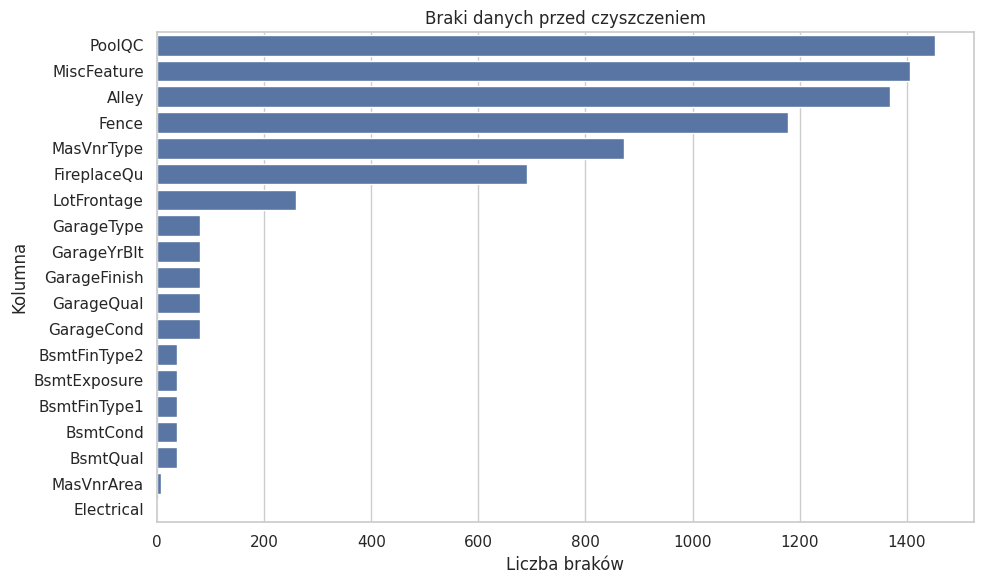

In [7]:
# Wykres liczby braków danych w kolumnach
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.values, y=missing_values.index)

plt.title("Braki danych przed czyszczeniem")
plt.xlabel("Liczba braków")
plt.ylabel("Kolumna")
plt.tight_layout()
plt.show()

**Wniosek:** kolumny z dużą liczbą braków wymagają specjalnego traktowania. W dalszej części część braków zostanie zastąpiona kategorią `None`, a część wartościami liczbowymi, np. `0` lub medianą.

## 6. Analiza zmiennej docelowej `SalePrice`

`SalePrice` jest zmienną, którą chcemy przewidywać. Najpierw sprawdzam jej rozkład.

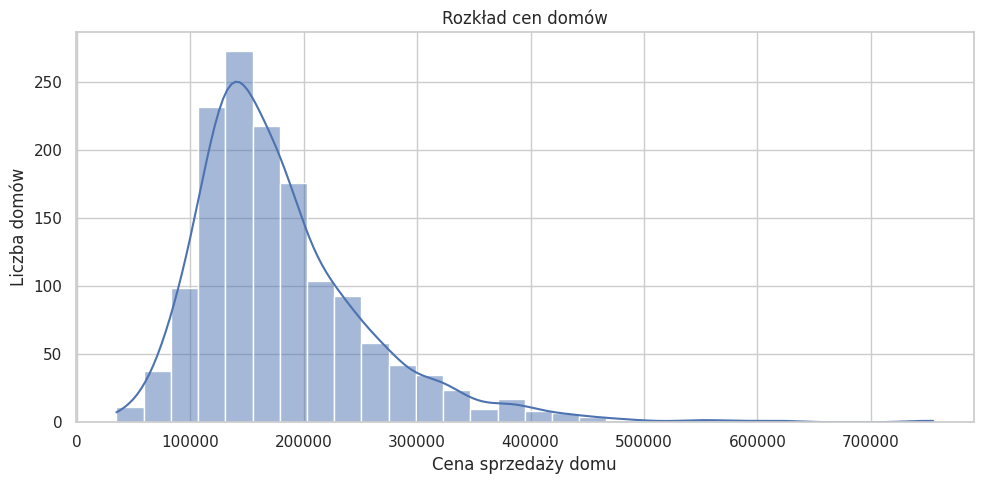

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [8]:
# Rozkład ceny sprzedaży domów
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, bins=30)

plt.title("Rozkład cen domów")
plt.xlabel("Cena sprzedaży domu")
plt.ylabel("Liczba domów")
plt.tight_layout()
plt.show()

display(df['SalePrice'].describe())

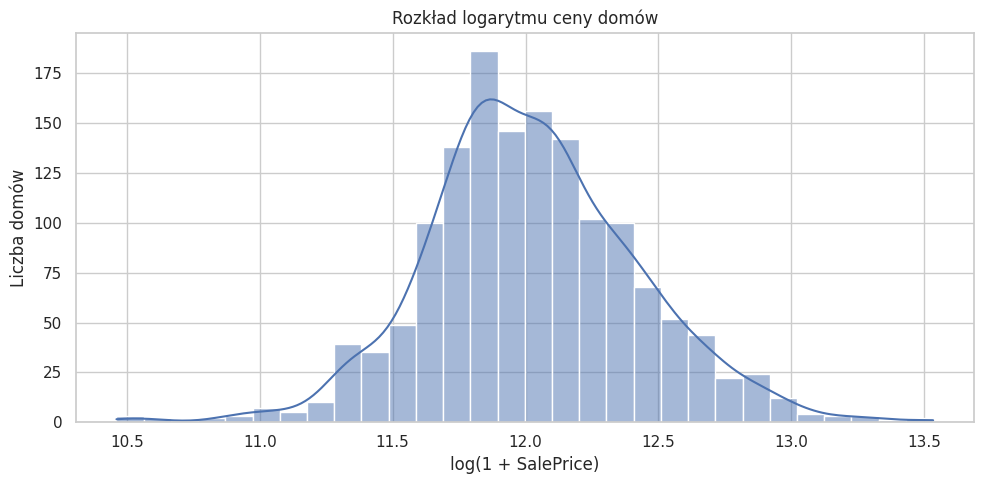

In [9]:
# Rozkład ceny po transformacji logarytmicznej
# Taka transformacja często pomaga modelom regresyjnym, gdy dane są prawostronnie skośne.
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['SalePrice']), kde=True, bins=30)

plt.title("Rozkład logarytmu ceny domów")
plt.xlabel("log(1 + SalePrice)")
plt.ylabel("Liczba domów")
plt.tight_layout()
plt.show()

## 7. Utworzenie kopii roboczych danych

Tworzę kopie `df1` i `testowe1`, aby nie nadpisywać oryginalnych danych. Na tych kopiach będą wykonywane czyszczenie, kodowanie i przygotowanie pod modele.

In [10]:
# Kopie robocze danych
# df1 — dane treningowe po czyszczeniu
# testowe1 — dane testowe po czyszczeniu
df1 = df.copy()
testowe1 = testowe.copy()

## 8. Identyfikacja zmiennych porządkowych

Część kolumn ma wartości tekstowe typu `Po`, `Fa`, `TA`, `Gd`, `Ex`. Są to zmienne porządkowe, bo oznaczają poziomy jakości od najgorszego do najlepszego.

Przykład kolejności:

`None < Po < Fa < TA < Gd < Ex`

In [11]:
# Szukamy kolumn tekstowych, które zawierają poziomy jakości
values_to_find = {'Po', 'Fa', 'TA', 'Gd', 'Ex'}
obj_cols = df.select_dtypes(include='object').columns

cols_with_quality_values = [
    col for col in obj_cols
    if df[col].isin(values_to_find).any()
]

print("Kolumny z wartościami jakościowymi:")
display(cols_with_quality_values)

Kolumny z wartościami jakościowymi:


['ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'HeatingQC',
 'KitchenQual',
 'FireplaceQu',
 'GarageQual',
 'GarageCond',
 'PoolQC']

In [12]:
# Podgląd unikalnych wartości dla najważniejszych kolumn jakościowych
quality_preview_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC',
    'GarageFinish', 'BsmtFinType1', 'BsmtFinType2'
]

for col in quality_preview_cols:
    print(f"{col}:")
    display(df[col].unique())

ExterQual:


array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

ExterCond:


array(['TA', 'Gd', 'Fa', 'Po', 'Ex'], dtype=object)

BsmtQual:


...

array(['RFn', 'Unf', 'Fin', nan], dtype=object)

BsmtFinType1:


array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

BsmtFinType2:


array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

## 9. Kodowanie zmiennych porządkowych

Zmieniam wartości tekstowe na liczby, ponieważ modele regresyjne wymagają danych numerycznych.

Przykład:
- `Po` = 1,
- `Fa` = 2,
- `TA` = 3,
- `Gd` = 4,
- `Ex` = 5.

Braki danych w tych kolumnach traktuję jako `None`, czyli brak danej cechy.

In [13]:
# Mapowanie ogólnych ocen jakości
qual_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

# Mapowanie ekspozycji piwnicy
exposure_map = {
    'None': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

# Kolumny z ocenami jakości/warunków
qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]

# Mapowanie wykończenia garażu
# None — brak garażu, Unf — unfinished, RFn — rough finished, Fin — finished
garage_finish_map = {
    'None': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}

# Mapowanie typu wykończenia piwnicy
bsmt_fin_map = {
    'None': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}

In [14]:
# Kodowanie kolumn porządkowych w danych treningowych
for col in qual_cols:
    df1[col] = df1[col].fillna('None').map(qual_map)

df1['BsmtExposure'] = df1['BsmtExposure'].fillna('None').map(exposure_map)
df1['GarageFinish'] = df1['GarageFinish'].fillna('None').map(garage_finish_map)
df1['BsmtFinType2'] = df1['BsmtFinType2'].fillna('None').map(bsmt_fin_map)
df1['BsmtFinType1'] = df1['BsmtFinType1'].fillna('None').map(bsmt_fin_map)

In [15]:
# To samo kodowanie wykonujemy dla danych testowych,
# aby train i test były przygotowane w spójny sposób.
for col in qual_cols:
    testowe1[col] = testowe1[col].fillna('None').map(qual_map)

testowe1['BsmtExposure'] = testowe1['BsmtExposure'].fillna('None').map(exposure_map)
testowe1['GarageFinish'] = testowe1['GarageFinish'].fillna('None').map(garage_finish_map)
testowe1['BsmtFinType2'] = testowe1['BsmtFinType2'].fillna('None').map(bsmt_fin_map)
testowe1['BsmtFinType1'] = testowe1['BsmtFinType1'].fillna('None').map(bsmt_fin_map)

## 10. Wizualizacja: jakość cech a cena domu

Poniższe wykresy pudełkowe pokazują, jak poziom jakości wybranych cech wiąże się z ceną sprzedaży domu.

Jeśli mediana ceny rośnie wraz z poziomem jakości, oznacza to, że dana cecha może mieć wpływ na cenę.

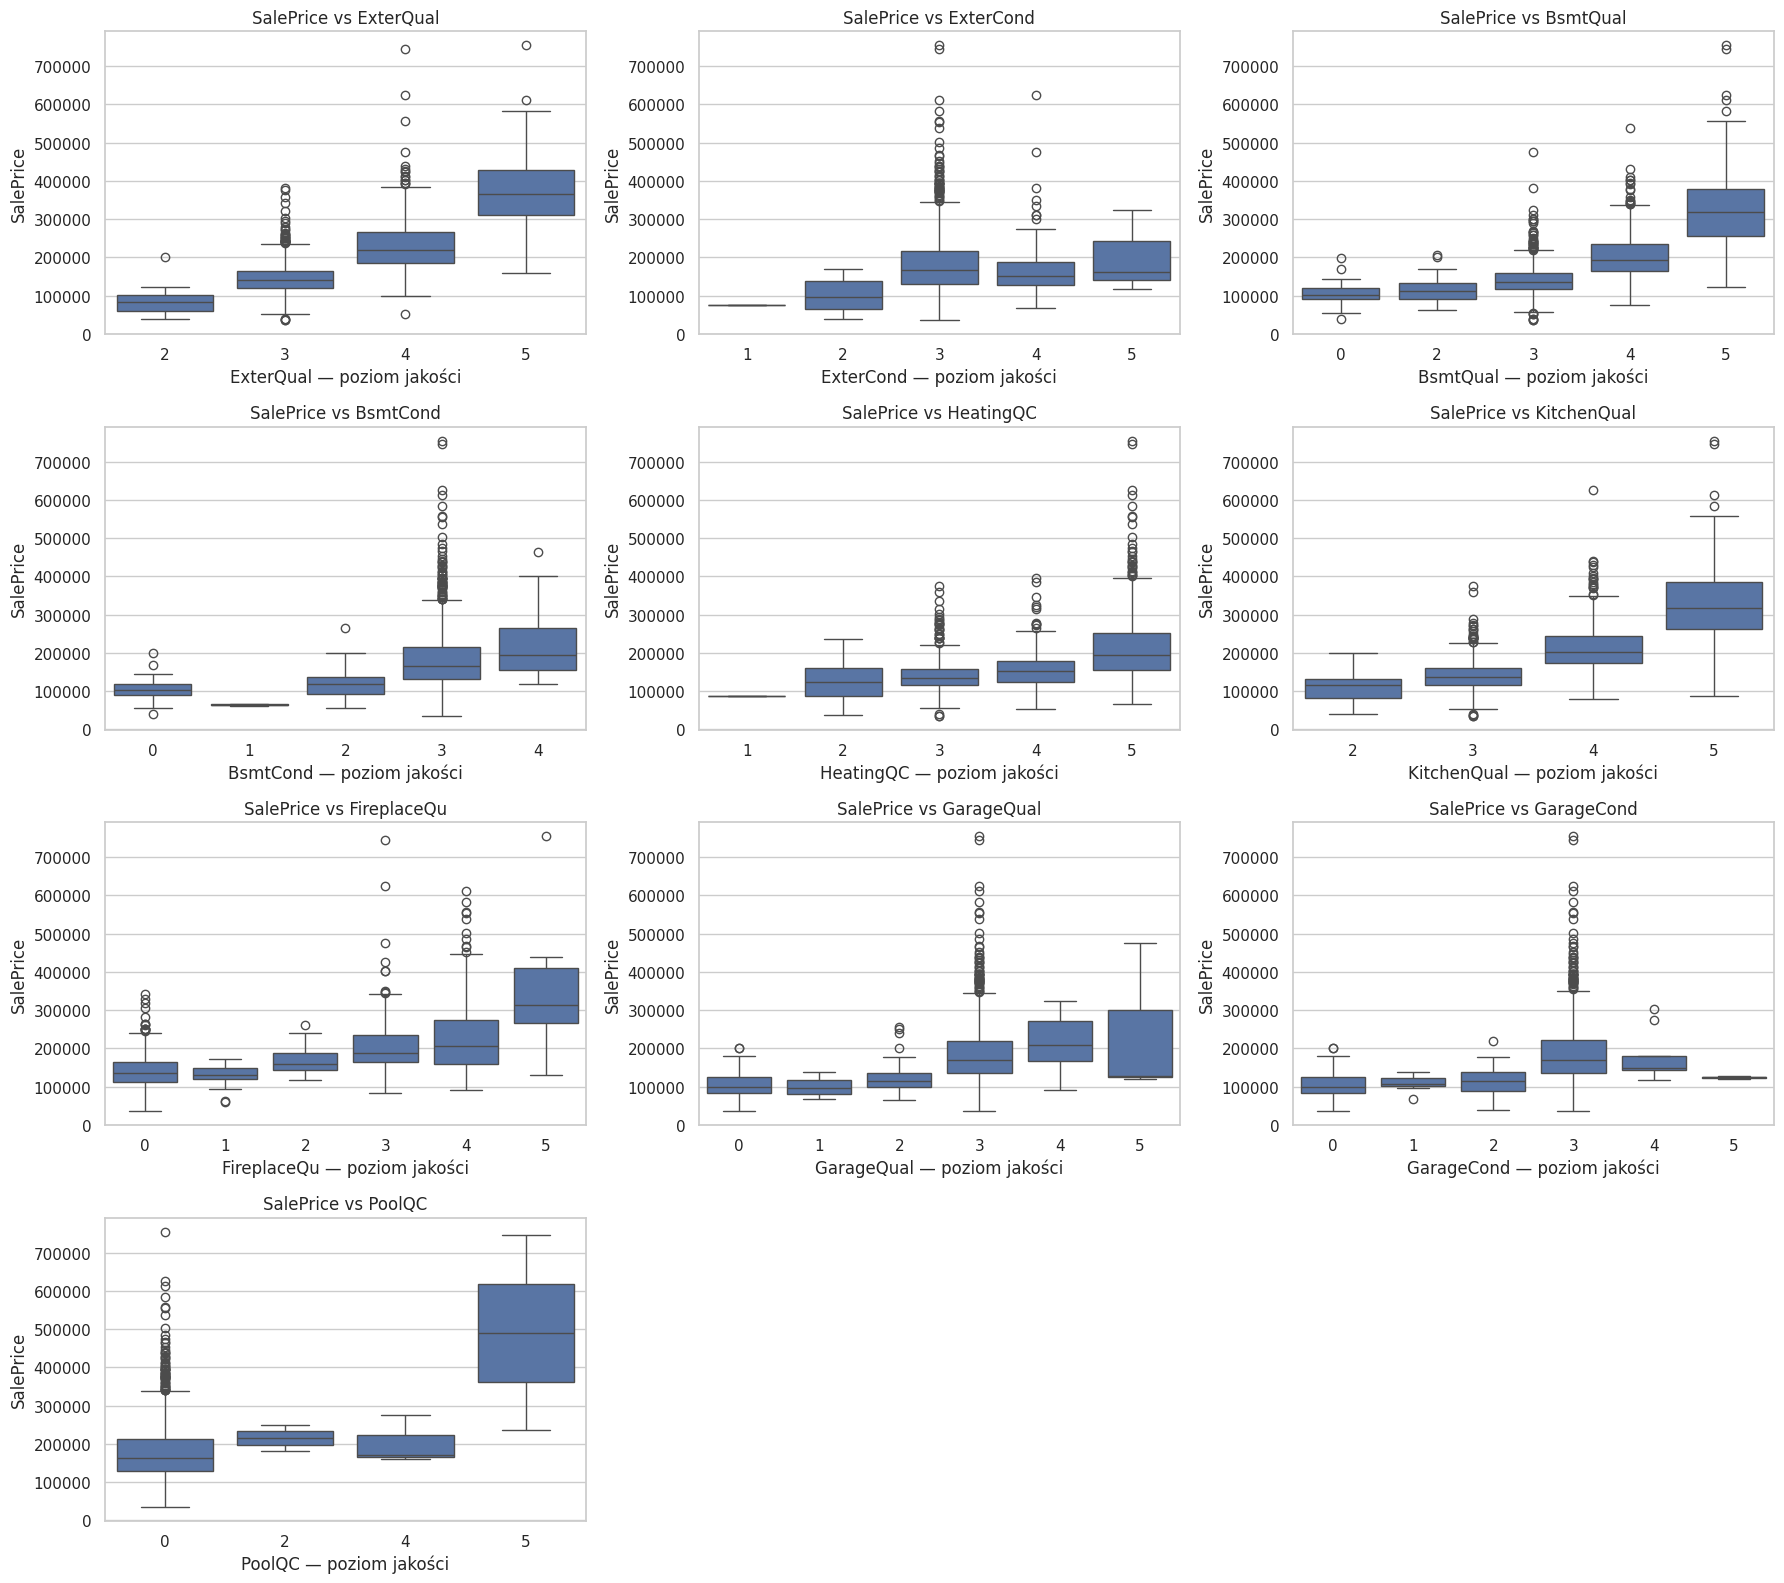

In [16]:
# Boxploty dla cech jakościowych po zakodowaniu na liczby
ncols = 3
nrows = math.ceil(len(qual_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(qual_cols):
    sns.boxplot(
        data=df1,
        x=col,
        y='SalePrice',
        ax=axes[i]
    )
    axes[i].set_title(f'SalePrice vs {col}')
    axes[i].set_xlabel(f'{col} — poziom jakości')
    axes[i].set_ylabel('SalePrice')

# Usunięcie pustych pól na siatce wykresów
for j in range(i + 1, len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

## 11. Kodowanie wybranych zmiennych nominalnych

Część zmiennych nie ma naturalnej kolejności, np. `GarageType` lub `Electrical`. Takie kolumny koduję metodą `get_dummies`, czyli one-hot encoding.

In [17]:
# Podgląd wybranych zmiennych nominalnych przed kodowaniem
nominal_preview_cols = ['MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'GarageType', 'Electrical']

for col in nominal_preview_cols:
    print(f"{col}:")
    display(df1[col].unique())

MiscFeature:


array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

Alley:


array([nan, 'Grvl', 'Pave'], dtype=object)

Fence:


...

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

GarageType:


array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

Electrical:


array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [18]:
# Kolumny nominalne kodowane przez one-hot encoding
cols_dummy = ['MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'GarageType', 'Electrical']

# Braki w tych kolumnach oznaczają najczęściej brak danej cechy, dlatego zastępuję je kategorią None.
for col in cols_dummy:
    df1[col] = df1[col].fillna('None')

df1 = pd.get_dummies(df1, columns=cols_dummy, drop_first=True)

In [19]:
# To samo kodowanie nominalne dla danych testowych
for col in cols_dummy:
    testowe1[col] = testowe1[col].fillna('None')

testowe1 = pd.get_dummies(testowe1, columns=cols_dummy, drop_first=True)

In [20]:
# Dodatkowe kolumny, które w tej wersji projektu są kodowane jako zmienne zero-jedynkowe.
# Dzięki temu model może traktować poziomy tych cech jako oddzielne kategorie.
cols_dummy2 = ['GarageFinish', 'BsmtFinType1', 'BsmtFinType2']

for col in cols_dummy2:
    df1[col] = df1[col].fillna('None')

df1 = pd.get_dummies(df1, columns=cols_dummy2, drop_first=True)

for col in cols_dummy2:
    testowe1[col] = testowe1[col].fillna('None')

testowe1 = pd.get_dummies(testowe1, columns=cols_dummy2, drop_first=True)

## 12. Analiza `LotFrontage`

`LotFrontage` oznacza szerokość działki od strony ulicy. Sprawdzam, czy większe wartości tej cechy są powiązane ze średnio wyższą ceną domu.

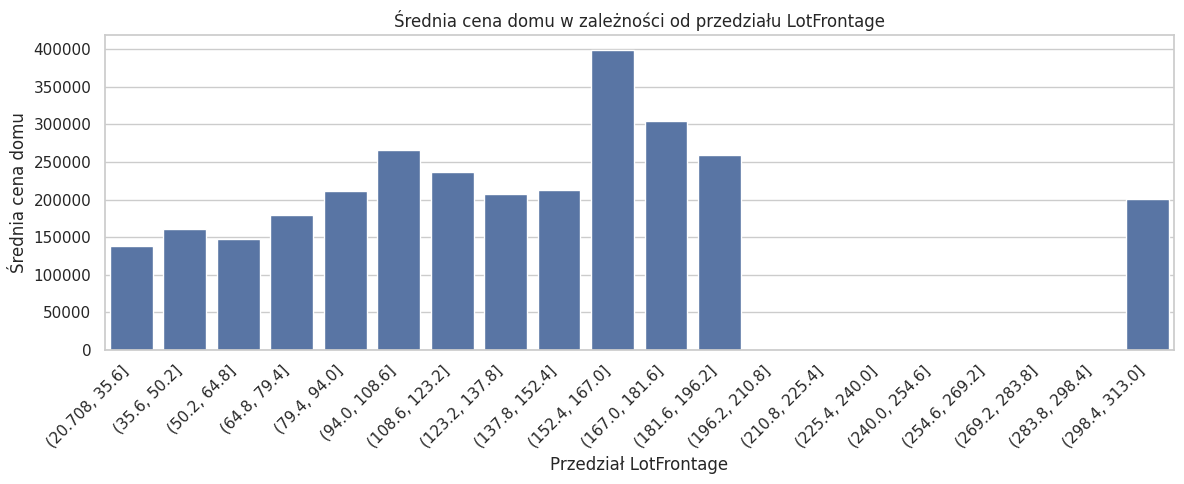

In [21]:
# Tworzymy kopię oryginalnych danych tylko do wykresu
# Następnie dzielimy LotFrontage na przedziały i liczymy średnią cenę w każdym przedziale.
df3 = df.copy()
df3['LotFrontage_bin'] = pd.cut(df3['LotFrontage'], bins=20)

tmp = df3.groupby('LotFrontage_bin', observed=False)['SalePrice'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=tmp, x='LotFrontage_bin', y='SalePrice')

plt.title('Średnia cena domu w zależności od przedziału LotFrontage')
plt.xlabel('Przedział LotFrontage')
plt.ylabel('Średnia cena domu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 13. Analiza cen według dzielnicy

Lokalizacja jest zwykle jednym z najważniejszych czynników wpływających na cenę nieruchomości. Dlatego sprawdzam średnią cenę domu w każdej dzielnicy.

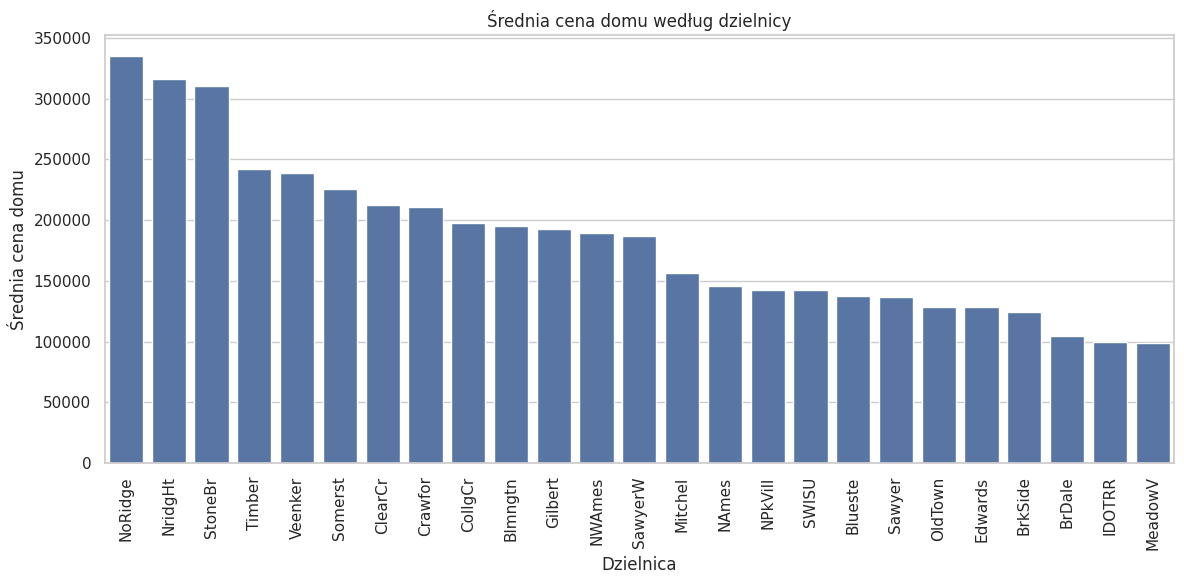

In [22]:
# Średnia cena domu w każdej dzielnicy
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=neighborhood_price.index, y=neighborhood_price.values)

plt.title("Średnia cena domu według dzielnicy")
plt.xlabel("Dzielnica")
plt.ylabel("Średnia cena domu")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 14. Uzupełnianie braków danych liczbowych

Dla `LotFrontage` braki uzupełniam medianą w obrębie `Neighborhood`, ponieważ szerokość działki może zależeć od dzielnicy. Jeśli nadal zostaną braki, używam mediany globalnej.

Dla `GarageYrBlt` oraz `MasVnrArea` braki zastępuję wartością `0`, ponieważ często oznaczają brak garażu lub brak powierzchni okładziny.

In [23]:
# Mediana LotFrontage dla każdej dzielnicy na podstawie danych treningowych
lotfront_median_by_neigh = df1.groupby('Neighborhood')['LotFrontage'].median()
lotfront_global_median = df1['LotFrontage'].median()

# Uzupełnianie LotFrontage w danych treningowych
df1['LotFrontage'] = df1['LotFrontage'].fillna(
    df1['Neighborhood'].map(lotfront_median_by_neigh)
)
df1['LotFrontage'] = df1['LotFrontage'].fillna(lotfront_global_median)
df1['LotFrontage'] = df1['LotFrontage'].fillna(df1['LotFrontage'].median())

# Uzupełnianie pozostałych wybranych kolumn liczbowych
df1['GarageYrBlt'] = df1['GarageYrBlt'].fillna(0)
df1['MasVnrArea'] = df1['MasVnrArea'].fillna(0)

In [24]:
# Uzupełnianie LotFrontage w danych testowych na podstawie median z danych treningowych
testowe1['LotFrontage'] = testowe1['LotFrontage'].fillna(
    testowe1['Neighborhood'].map(lotfront_median_by_neigh)
)
testowe1['LotFrontage'] = testowe1['LotFrontage'].fillna(lotfront_global_median)

# Uzupełnianie pozostałych wybranych kolumn liczbowych w danych testowych
testowe1['GarageYrBlt'] = testowe1['GarageYrBlt'].fillna(0)
testowe1['MasVnrArea'] = testowe1['MasVnrArea'].fillna(0)

In [25]:
# Sprawdzenie braków danych po wykonaniu części czyszczenia
print("Braki w df1 po czyszczeniu:")
display(df1.isna().sum()[df1.isna().sum() > 0])

print("Braki w testowe1 po czyszczeniu:")
display(testowe1.isna().sum()[testowe1.isna().sum() > 0])

Braki w df1 po czyszczeniu:


Series([], dtype: int64)

Braki w testowe1 po czyszczeniu:


MSZoning        4
Utilities       2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64

### Podsumowanie czyszczenia danych

In [26]:
cleaning_summary = pd.DataFrame({
    'Etap': [
        'Utworzenie kopii danych',
        'Kodowanie zmiennych porządkowych',
        'One-hot encoding zmiennych nominalnych',
        'Uzupełnienie LotFrontage',
        'Uzupełnienie GarageYrBlt i MasVnrArea',
        'Wyrównanie kolumn train/test przed predykcją'
    ],
    'Opis': [
        'Utworzono df1 i testowe1, aby nie zmieniać oryginalnych danych.',
        'Zmieniono poziomy jakości, np. Po/Fa/TA/Gd/Ex, na liczby.',
        'Zmienne bez naturalnej kolejności zakodowano przez pd.get_dummies().',
        'Braki uzupełniono medianą dla danej dzielnicy, a potem medianą globalną.',
        'Braki zastąpiono wartością 0, interpretowaną jako brak danej cechy.',
        'Po get_dummies dane testowe zostaną dopasowane do kolumn danych treningowych.'
    ]
})

display(cleaning_summary)

,Etap,Opis
0,Utworzenie kopii danych,"Utworzono df1 i testowe1, aby nie zmieniać ory..."
1,Kodowanie zmiennych porządkowych,"Zmieniono poziomy jakości, np. Po/Fa/TA/Gd/Ex,..."
2,One-hot encoding zmiennych nominalnych,Zmienne bez naturalnej kolejności zakodowano p...
3,Uzupełnienie LotFrontage,"Braki uzupełniono medianą dla danej dzielnicy,..."
4,Uzupełnienie GarageYrBlt i MasVnrArea,"Braki zastąpiono wartością 0, interpretowaną j..."
5,Wyrównanie kolumn train/test przed predykcją,Po get_dummies dane testowe zostaną dopasowane...


## 15. Korelacje numeryczne z `SalePrice`

Korelacja pokazuje siłę liniowego związku między zmiennymi. Tutaj sprawdzam, które cechy numeryczne są najmocniej powiązane z ceną domu.

In [27]:
# Korelacje zmiennych numerycznych z ceną domu
num_df = df.select_dtypes(include=['int64', 'float64'])
corr_with_target = num_df.corr()['SalePrice'].sort_values(ascending=False)

# Pokazujemy tylko silniejsze zależności, np. powyżej 0.4 lub poniżej -0.4
strong_corr = corr_with_target[abs(corr_with_target) > 0.4]

display(strong_corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
Name: SalePrice, dtype: float64

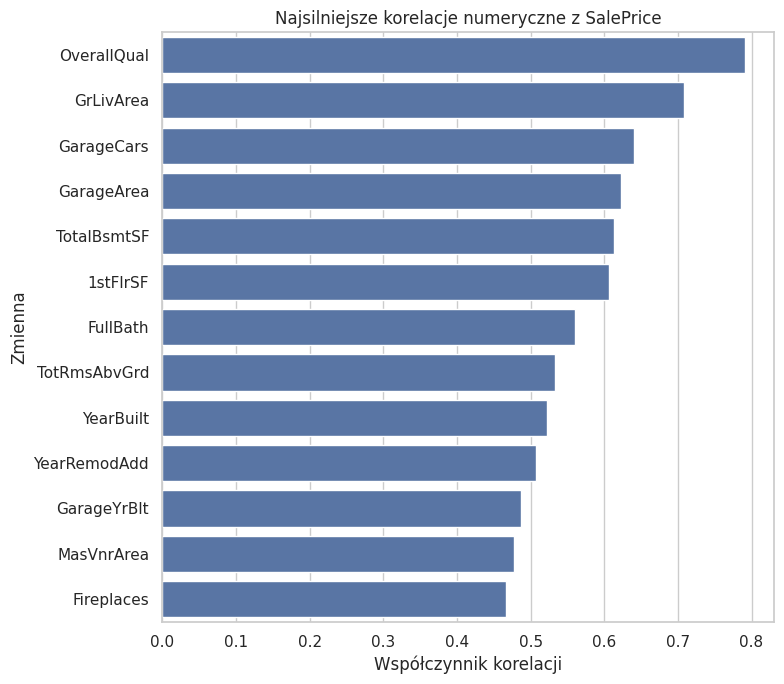

In [28]:
# Wykres silniejszych korelacji z SalePrice
strong_corr_without_target = strong_corr.drop('SalePrice', errors='ignore')

plt.figure(figsize=(8, 7))
sns.barplot(x=strong_corr_without_target.values, y=strong_corr_without_target.index)

plt.title('Najsilniejsze korelacje numeryczne z SalePrice')
plt.xlabel('Współczynnik korelacji')
plt.ylabel('Zmienna')
plt.tight_layout()
plt.show()

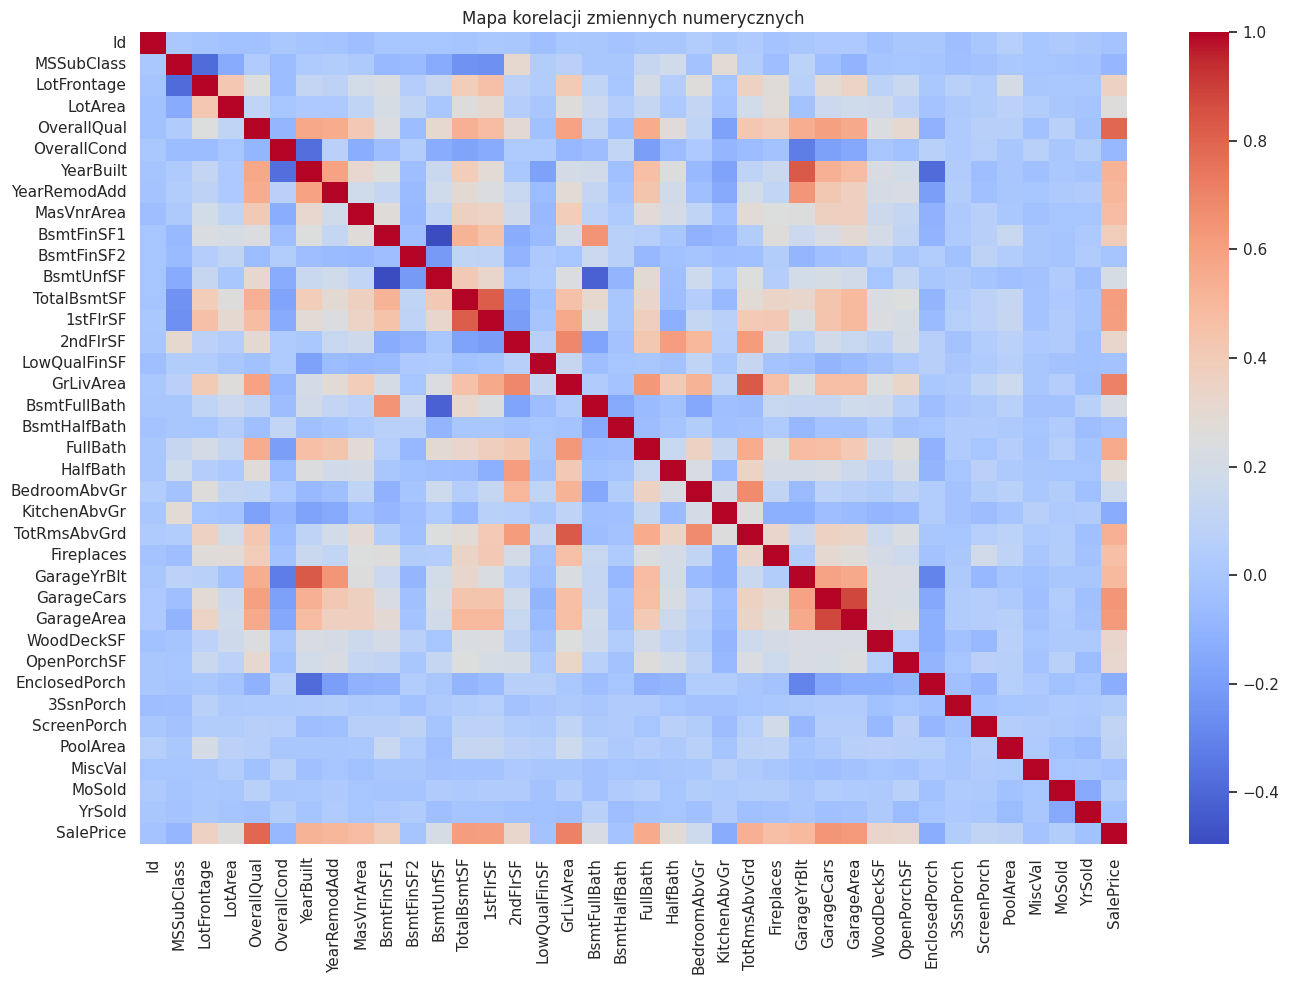

In [29]:
# Heatmapa korelacji dla zmiennych numerycznych
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include=['int64', 'float64']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Mapa korelacji zmiennych numerycznych')
plt.tight_layout()
plt.show()

## 16. Zależność powierzchni mieszkalnej od ceny

Sprawdzam, czy większa powierzchnia mieszkalna nad poziomem gruntu (`GrLivArea`) wiąże się z wyższą ceną domu.

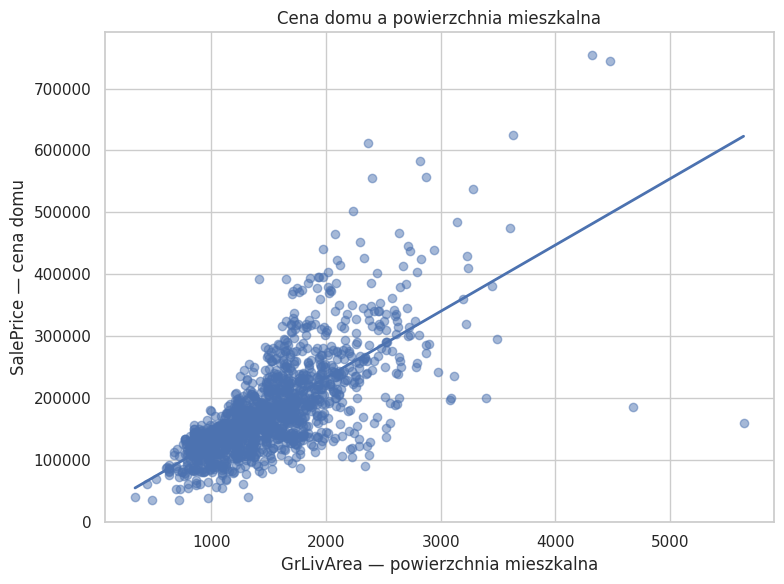

Współczynnik regresji: 107.1303589658252
Wyraz wolny: 18569.02585648722


In [30]:
# Wykres punktowy z linią regresji
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='GrLivArea',
    y='SalePrice',
    ci=None,
    scatter_kws={'alpha': 0.5},
    line_kws={'linewidth': 2}
)

plt.title("Cena domu a powierzchnia mieszkalna")
plt.xlabel("GrLivArea — powierzchnia mieszkalna")
plt.ylabel("SalePrice — cena domu")
plt.tight_layout()
plt.show()

# Prosty model regresji liniowej tylko dla jednej zmiennej
X_single = df[['GrLivArea']]
y_single = df['SalePrice']

single_model = LinearRegression()
single_model.fit(X_single, y_single)

print("Współczynnik regresji:", single_model.coef_[0])
print("Wyraz wolny:", single_model.intercept_)

## 17. Metody statystyczne

W tej części wykorzystuję metody statystyczne, aby lepiej odpowiedzieć na pytania badawcze:
- korelację Pearsona,
- korelację Spearmana,
- test ANOVA.

In [31]:
# Korelacja Pearsona i Spearmana dla GrLivArea i SalePrice
# Pearson bada zależność liniową, a Spearman monotoniczną.
pearson_corr, pearson_p = pearsonr(df['GrLivArea'], df['SalePrice'])
spearman_corr, spearman_p = spearmanr(df['GrLivArea'], df['SalePrice'])

print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4e}")
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")

Pearson correlation: 0.7086, p-value: 4.5180e-223
Spearman correlation: 0.7313, p-value: 1.4310e-244


In [32]:
# ANOVA: sprawdzenie, czy średnia cena różni się między poziomami OverallQual
# H0: średnie ceny w grupach OverallQual są takie same.
# H1: przynajmniej jedna grupa ma inną średnią cenę.
groups = [
    group['SalePrice'].values
    for _, group in df.groupby('OverallQual')
    if len(group) > 1
]

anova_result = f_oneway(*groups)

print("ANOVA statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

ANOVA statistic: 349.02683956930736
p-value: 0.0


## 18. Przygotowanie danych do modelowania

Przed trenowaniem modelu:
- usuwam `SalePrice` z cech, ponieważ jest to zmienna docelowa,
- usuwam `Id`, ponieważ jest identyfikatorem, a nie cechą opisującą dom,
- pozostałe zmienne kategoryczne koduję przez `get_dummies`.

In [33]:
# Przygotowanie X i y
X = df1.drop(columns=['SalePrice', 'Id'])
y = df1['SalePrice']

# Kontrola, czy zostały jeszcze jakieś kolumny tekstowe
print("Kolumny tekstowe przed końcowym get_dummies:")
display(X.select_dtypes(include='object').columns)

# Końcowe kodowanie pozostałych zmiennych kategorycznych
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Rozmiar macierzy cech po kodowaniu:", X.shape)

Kolumny tekstowe przed końcowym get_dummies:


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'Foundation', 'Heating', 'CentralAir', 'Functional',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

Rozmiar macierzy cech po kodowaniu: (1460, 227)


In [34]:
# Podgląd nazw kolumn po przetworzeniu
cols = X.columns.tolist()
for i in range(0, len(cols), 10):
    print(cols[i : i + 10])

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond']
['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF']
['LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd']
['Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch']
['3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'MiscVal', 'MoSold', 'YrSold', 'MiscFeature_None', 'MiscFeature_Othr', 'MiscFeature_Shed']
['MiscFeature_TenC', 'Alley_None', 'Alley_Pave', 'Fence_GdWo', 'Fence_MnPrv', 'Fence_MnWw', 'Fence_None', 'MasVnrType_BrkFace', 'MasVnrType_None', 'MasVnrType_Stone']
['GarageType_Attchd', 'GarageType_Basment', 'GarageType_BuiltIn', 'GarageType_CarPort', 'GarageType_Detchd', 'GarageType_

## 19. Model bazowy — regresja liniowa

Pierwszym modelem jest regresja liniowa. Używam pipeline, który najpierw standaryzuje dane, a następnie trenuje model.

In [35]:
# Podział danych na zbiór treningowy i walidacyjny
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: standaryzacja + regresja liniowa
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Trenowanie modelu
pipeline.fit(X_train, y_train)

# Predykcja na zbiorze walidacyjnym
y_pred = pipeline.predict(X_test)

# Ocena modelu
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 218939710099588.28
R2: -6.249355681063063e+18


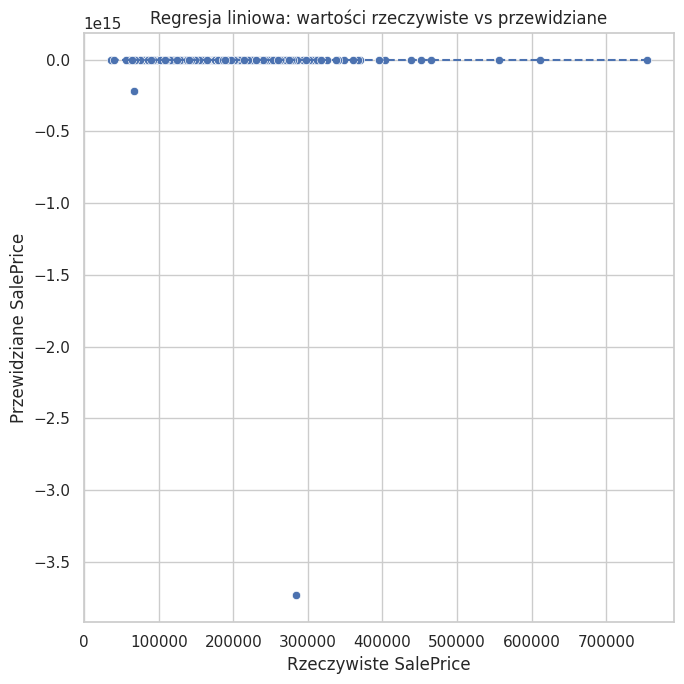

In [36]:
# Wykres: wartości rzeczywiste vs przewidziane dla regresji liniowej
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title('Regresja liniowa: wartości rzeczywiste vs przewidziane')
plt.xlabel('Rzeczywiste SalePrice')
plt.ylabel('Przewidziane SalePrice')
plt.tight_layout()
plt.show()

## 20. Uzupełnienie braków w danych testowych przed predykcją

W danych testowych uzupełniam dodatkowe kolumny liczbowe wartością `0`, aby model mógł wykonać predykcję.

In [37]:
# Kolumny liczbowe, w których brak danych można interpretować jako brak danej cechy
cols_zero = [
    'BsmtHalfBath', 'BsmtFullBath', 'BsmtFinSF1', 'BsmtFinSF2',
    'TotalBsmtSF', 'BsmtUnfSF', 'GarageCars', 'GarageArea'
]

for col in cols_zero:
    testowe1[col] = testowe1[col].fillna(0)

## 21. Model końcowy — Gradient Boosting Regressor

Drugi model to `GradientBoostingRegressor`. Dodatkowo stosuję logarytm z ceny (`np.log1p`), aby ograniczyć wpływ bardzo drogich domów i poprawić stabilność modelu.

In [38]:
target = 'SalePrice'
id_col = 'Id'

# 1. Cechy i target z danych treningowych
X = df1.drop(columns=[target, id_col], errors='ignore')
y = df1[target]

# 2. Dane do końcowej predykcji z testowe1
X_finalne = testowe1.drop(columns=[id_col, target], errors='ignore')

# 3. Zamiana pozostałych kolumn kategorycznych na dummy variables
X = pd.get_dummies(X, drop_first=True, dtype=int)
X_finalne = pd.get_dummies(X_finalne, drop_first=True, dtype=int)

# 4. Wyrównanie kolumn danych testowych do danych treningowych
# Jeżeli w testowym zbiorze brakuje jakiejś kolumny dummy, zostanie dodana z wartością 0.
X_finalne = X_finalne.reindex(columns=X.columns, fill_value=0)

# 5. Logarytm ze zmiennej docelowej
# np.log1p(y) = log(1 + y), bezpieczne dla wartości dodatnich.
y_log = np.log1p(y)

# 6. Podział danych treningowych na train/test do walidacji modelu
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 7. Definicja modelu Gradient Boosting
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=4,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

# 8. Trenowanie modelu na części treningowej
model.fit(X_train, y_train)

# 9. Sprawdzenie jakości na części walidacyjnej
y_pred_log = model.predict(X_test)

# Cofnięcie logarytmu, aby metryki liczyć w rzeczywistych cenach
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print(f"MAE na danych walidacyjnych: {mae:.2f}")
print(f"RMSE na danych walidacyjnych: {rmse:.2f}")
print(f"R2 na danych walidacyjnych: {r2:.4f}")

MAE na danych walidacyjnych: 16557.83
RMSE na danych walidacyjnych: 29618.37
R2 na danych walidacyjnych: 0.8856


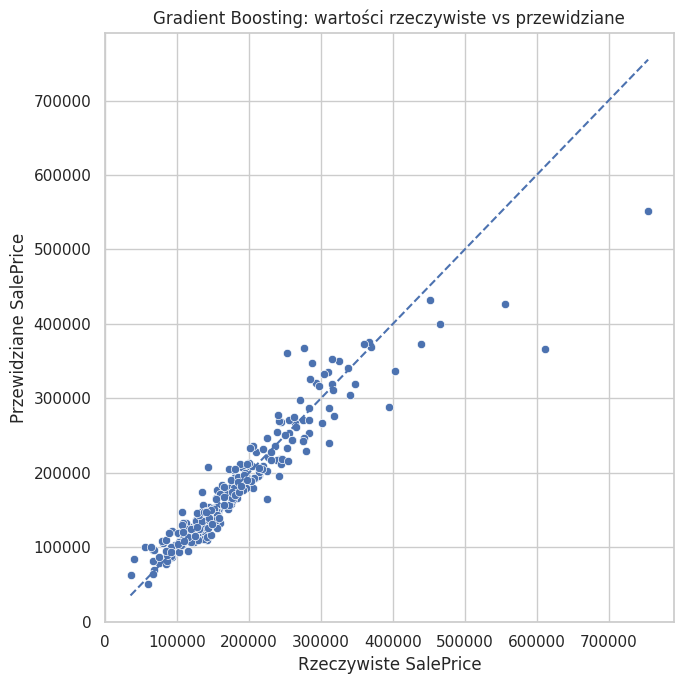

In [39]:
# Wykres: wartości rzeczywiste vs przewidziane dla Gradient Boosting
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test_real, y=y_pred_real)

plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    linestyle='--'
)

plt.title('Gradient Boosting: wartości rzeczywiste vs przewidziane')
plt.xlabel('Rzeczywiste SalePrice')
plt.ylabel('Przewidziane SalePrice')
plt.tight_layout()
plt.show()

In [40]:
# 10. Trenowanie modelu na całym zbiorze treningowym
model.fit(X, y_log)

# 11. Predykcja na danych testowych
wyniki_log = model.predict(X_finalne)
wyniki = np.expm1(wyniki_log)

# 12. Złożenie wyników w formacie do pliku submission.csv
predykcje_df = testowe1[[id_col]].copy()
predykcje_df[target] = wyniki

display(predykcje_df.head())

# 13. Zapis do pliku CSV
predykcje_df.to_csv("submission.csv", index=False)

,Id,SalePrice
0,1461,124723.722960
1,1462,158881.634109
2,1463,181464.929400
3,1464,183573.728429
4,1465,192516.490608


In [41]:
# Końcowa kontrola, czy w danych do predykcji nie zostały braki
X_finalne.isna().sum()[X_finalne.isna().sum() > 0]

Series([], dtype: int64)

## 22. Podsumowanie projektu

W projekcie wykonano:

- wczytanie danych treningowych i testowych,
- analizę braków danych,
- wizualizacje rozkładu ceny i zależności między cechami a ceną,
- kodowanie zmiennych kategorycznych,
- uzupełnianie braków danych,
- analizę korelacji,
- użycie metod statystycznych: Pearson, Spearman, ANOVA,
- zbudowanie modelu regresji liniowej,
- zbudowanie modelu Gradient Boosting,
- wygenerowanie pliku `submission.csv` z predykcjami.

Najważniejsze cechy wpływające na cenę domu to zwykle jakość nieruchomości, powierzchnia mieszkalna, garaż, piwnica oraz lokalizacja.